## 특성 공학과 규제

### 다중 회귀

다중회귀(multiple regression)

- 여러 개의 특성을 사용한 선형 회귀

- 1개의 특성을 사용했을 때 선형 회귀 모델이 학습하는 것 -> 직선

- 2개의 특성을 사용했을 때 선형 회귀 모델이 학습하는 것 -> 평면

- 특성이 2개면 타깃값과 함께 3차원 공간을 형성

- 선형 회귀 방정식 '타깃 = a * 특성1 + b * 특성2 + 절편'은 평면이 됨

- 우리는 3차원 공간 이상을 그리거나 상상할 수 없음

- 선형 회귀를 단순한 직선이나 평면으로 생각하여 성능이 무조건 낮다고 오해하면 안됨
- 특성이 많은 고차원에서는 선형 회귀가 매우 복잡한 모델을 표현할 수 있음

- 특성 공학 (feature engineering)

- 기존의 특성을 사용해 새로운 특성을 뽑아내는 작업

### 데이터 준비

- 판다스(pandas) -> 데이터 분석 라이브러리

- 데이터프레임(dataframe) -> 판다스의 핵심 데이터 구조
- 넘파이 배열과 비슷하게 다차원 배열을 다룰 수 있지만 훨씬 더 많은 기능을 제공함
- 데이터 프레임은 넘파이 배열로 쉽게 바꿀 수 있음

- 판다스를 사용해 농어 데이터를 인터넷에서 내려받아 데이터프레임에 저장

- 넘파이 배열로 변환하여 선형 회귀 모델 훈련

In [24]:
import pandas as pd
df = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full = df.to_numpy()
print(perch_full)

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [25]:
# 타깃 데이터
import numpy as np
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0, 1000.0])
print(perch_weight) 

[   5.9   32.    40.    51.5   70.   100.    78.    80.    85.    85.
  110.   115.   125.   130.   120.   120.   130.   135.   110.   130.
  150.   145.   150.   170.   225.   145.   188.   180.   197.   218.
  300.   260.   265.   250.   250.   300.   320.   514.   556.   840.
  685.   700.   700.   690.   900.   650.   820.   850.   900.  1015.
  820.  1100.  1000.  1100.  1000.  1000. ]


In [26]:
# 훈련 세트와 테스트 세트로 나누기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    perch_full, perch_weight, random_state=42)

### 사이킷런의 변환기

- 사이킷런은 특성을 만들거나 전처리하기 위한 다양한 클래스를 제공

- 사이킷런에서는 이런 클래스를 변환기(transfomer)라고 부름
- - 특성을 만들거나 전처리하는 클래스
- 변환기 클래스는 모두 fit(), transform() 메서드를 제공

In [27]:
from sklearn.preprocessing import PolynomialFeatures

In [28]:
# 2개의 특성과 2와 3으로 이루어진 샘플 적용
poly = PolynomialFeatures()
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

[[1. 2. 3. 4. 6. 9.]]


- transform 전에 꼭 poly.fit을 사용해야 함

- 훈련(fit)을 해야 변환(transform)이 가능함
- 사이킷런의 일관된 api 때문에 두 단계로 나뉘어져 있음
- 두 메서드를 하나로 붙인 fit_transform 메서드도 있음

- fit() 메서드는 새롭게 만들 특성 조합을 찾음
- tranform() 메서드는 실제로 데이터를 변환

- 변환기는 입력 데이터를 변환하는 데 타깃 데이터가 필요하지 않음
- - 변환기는 타깃 데이터 없이 입력 데이터를 변환

- 따라서 모델 클래스와는 다르게 fit() 메서드에 입력 데이터만 전달

- polynomialFeatures 클래스는 기본적으로 각 특성을 제곱한 항을 추가하고 특성끼리 곱한 항을 추가

- 무게 = a * 길이 + b * 높이 + c * 두께 + d * 1

- 선형 방정식의 절편을 항상 값이 1인 특성과 곱해지는 계수
- 이렇게 놓고 보면 특성은 (길이, 높이, 두께, 1)이 됨
- 하지만 사이킷헌의 선형 모델은 자동으로 절편을 추가하므로 궅이 이렇게 특성을 만들 필요 없음
- include_bais = False로 지정하여 다시 특성 변환

In [29]:
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

[[2. 3. 4. 6. 9.]]


- 절편을 위한 항이 제거되고 특성의 제곱과 특성끼리 곱한 항만 추가됨!

- include_bias = False로 지정하지 않아도 사이킷런 모델은 자동으로 특성에 추가된 절평 항을 무시함


In [30]:
# 이 방식으로 train_input에 적용
# train_input을 변환한 데이터를 train_poly에 저장하고 배열 크기 확인
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape)

(42, 9)


- PolynomialFeatures 클래스는 9개의 특성이 어떻게 만들어졌는제 확인하는 방법 제공

- get_feature_names_out() 메서드를 호출하면 9개의 특성이 각각 어떤 입력의 조합으로 만들어졌는지 알려줌

In [31]:
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

- 'x1'은 첫 번째 특성

- 'x0^2'은 첫 번쩨 특성의 제곱
- 'x0 x1'은 첫 번째 특성과 두 번째 특성의 곱

In [32]:
# 테스트 세트 변환
test_poly = poly.transform(test_input)

- polynomialFeatures 클래스는 fit() 메서드에서 만들 특성의 조합을 준비하기만 하고 별도의 통계값을 구하지 않음

- 따라서 테스트 세트를 따로 변환해도 됨

### 다중 회귀 모델 훈련하기

- 다중 회귀 모델을 훈련하는 것은 선형 회귀 모델을 훈련하는 것과 같음

- 다만 여러 개의 특성을 사용하여 선형 회귀를 수행하는 것뿐


In [33]:
# LinearRegression 클래스를 임포트하고 앞에서 만든 train_poly를 사용해 모델을 훈련
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.9903183436982125


- 특성이 늘어나면 선형 회귀의 능력은 매우 강함

In [34]:
# 테스트 세트 점수 확인
print(lr.score(test_poly, test_target))

0.9714559911594159


- polynomialFeatures 클래스의 degree 매개변수를 사용하여 필요한 고차항의 최대 차수를 지정할 수 있음

In [35]:
# 5제곱까지 특성을 만들어 출력
poly = PolynomialFeatures(degree = 5, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape)

(42, 55)


- train_poly 배열의 열의 개수가 특성의 개수


In [36]:
# 이 데이터를 사용해 선형 회귀 모델을 다시 훈련
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.999999999999769


In [37]:
# 테스트 세트 점수
print(lr.score(test_poly, test_target))

-144.40490595353674


- 특성의 개수를 크게 늘리면 선형 모델은 강력해짐

- 훈련 세트에 대해 거의 완벽하게 학습할 수 있음
- 하지만 이런 모델은 훈련 세트에 너무 과대적합되므로 테스트 세트에서는 형편없는 점수를 만든다

### 규제

규제(regularization)

- 머신러닝이 모델이 훈련 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것
- 모델이 훈련 세트에 과대적합되지 않도록 만드는 것

- 선형 회귀 모델의 경우 특성에 곱해지는 계수(또는 기울기)의 크기를 작게 만드는 것

- 특성의 스케일

- 특성의 스케일이 정규화되지 않으면 여기에 곱해지는 계수 값도 차이 나게됨
- 일반적으로 선형 회귀 모델이 규제를 적용할 때 계수 값의 크기가 서로 많이 다르면 공정하게 제어되지 않음
- 그래서 규제를 적용하기 전에 먼저 정규화 필요!

- 사이킷런의 StandardScaler 클래스 사용

In [38]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

- 먼저 StandardScaler 클래스의 객체 ss를 초기화한 후 PolynomialFeatures 클래스로 만든 train_poly를 사용해 객체 훈련

- 꼭 훈련 세트로 학습한 변환기를 사용해 테스트 세트까지 변환해야 함

- 선형 회귀 모델에 규제를 추가한 모델을 릿지(ridge)와 라쏘(lasso)라고 부름
- 두 모델은 규제를 가하는 방법이 다름

- 릿지 -> 계수를 제곱한 값을 기준으로 규제를 적용
- 라쏘 -> 계수의 절댓값을 기준으로 규제 적용
- 일반적으로 릿지를 조금 더 선호함
- 두 알고리즘 모두 계수의 크기를 줄이지만 라쏘는 아예 0으로 만들 수 있음

### 릿지 회귀

- 릿지와 라쏘 모두 sklearn.linear_model 패키지 안에 있음

- 사이킷런 모델을 사용할 때 편리한 점은 훈련하고 사용하는 방법이 항상 같다는 것
- 모델 객체를 만들고 fit() 메서드에서 훈련한 다음 score() 메서드로 평가

In [39]:
# train_scaled 데이터로 릿지 모델 훈련
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))

0.9896101671037343


In [40]:
# 테스트 점수 확인
print(ridge.score(test_scaled, test_target))

0.9790693977615388


- 릿지와 라쏘 모델을 사용할 때 규제의 양을 임의로 조절할 수 있음

- 모델 객채를 만들 때 alpha 매개변수로 규제의 강도를 조절함
- alpha 값이 크면 규제 강도가 세지므로 계수 값을 더 줄이고 조금 더 과소적합되도록 유도
- alpha 값이 작으면 계수를 줄이는 역할이 줄어들고 선형 회귀 모델과 유사해지므로 과대적합될 가능성이 큼

- alpha 값은 릿지 모델이 학습하는 값이 아니라 가전에 우리가 지정해야 하는 값

- 하이퍼파라미터(hyperparameter) : 머신러닝 모델이 학습할 수 없고 사람이 알려줘야 하는 파라미터
- 사이킷런과 같은 머신러닝 알고리즘에서 하이퍼퍼라미터는 클래스와 메서드의 매개변수로 표현


- 적절한 alpha 값을 찾는 한 가지 방법은 alpha 값에 대한 R^2 값의 그래프를 그려보는 것

- 훈련 세트와 테스트 세트의 점수가 가장 가까운 지점이 최적의 alpha 값이 됨


In [50]:
# 맷플롯립 임포트
# alpha 값을 바꿀 때마다 score() 메서드의 결과를 저장할 리스트 만들기
import matplotlib.pyplot as plt
train_score = []
test_score = []

In [51]:
# alpha 값을 0.001에서 100까지 10배씩 늘려가며 릿지 회귀 모델 훈련
# 훈련 세트와 테스트 세트의 점수를 파이썬 리스트에 저장
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    # 릿지 모델 만들기
    ridge = Ridge(alpha=alpha)    
    # 릿지 모델 훈련
    ridge.fit(train_input, train_target)
    # 훈련 점수와 테스트 점수 저장
    train_score.append(ridge.score(train_input, train_target))
    test_score.append(ridge.score(test_input, test_target))

In [53]:
# alpha 값을 0.1로 하여 최종 모델 훈련
ridge = Ridge(alpha = 0.1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9903815817570366
0.9827976465386955


### 라쏘 회귀

- ridge 클래스를 lasso 클래스로 바꾸면됨

In [54]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))

0.989789897208096


In [55]:
# 테스트 세트 점수 확인
print(lasso.score(test_scaled, test_target))

0.9800593698421884


- 라쏘 모델도 alpha 매개변수로 규제의 강도 조절 가능


In [60]:
# alpha 값을 바꿔가며 훈련 세트와 테스트 세트에 대한 점수 계산
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    # 라쏘 모델 만들기
    lasso = Lasso(alpha=alpha, max_iter=10000)
    # 라쏘 모델 훈련
    lasso.fit(train_scaled, train_target)
    # 훈련 세트와 테스트 세트 저장
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target)) 

/Users/youju/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/Users/youju/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


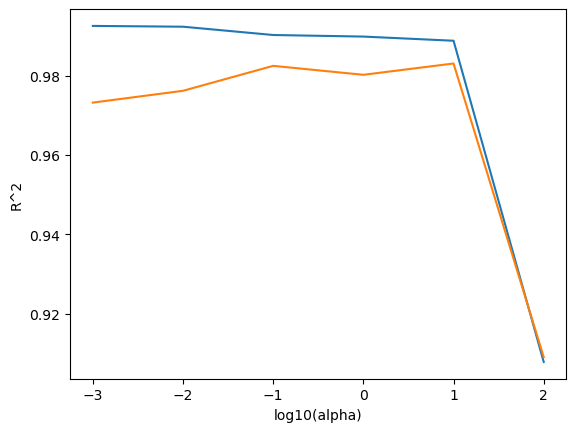

In [61]:
# 그래프 그리기
# x축은 로그 스케일로
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('log10(alpha)')
plt.ylabel('R^2')
plt.show()

- 왼쪽은 과대적합, 오른쪽으로 갈수록 훈련 세트와 테스트 세트의 점수가 좁혀짐

- 오른쪽은 과소적함

In [62]:
# 최적의 alpha값 1으로 모델 다시 훈련
lasso = Lasso(alpha = 10)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.9888067471131867
0.9824470598706695


In [63]:
# 라쏘 모델의 계수 값이 0인 것
print(np.sum(lasso.coef_ == 0))

40
